<a href="https://colab.research.google.com/github/Abiliger/Intelligent-analysis-and-data-visualization/blob/main/naive_bayes_classification/lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import seaborn as sns
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
from google.colab import files
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.naive_bayes import GaussianNB
from mlxtend.plotting import plot_decision_regions

This section imports all the libraries and modules necessary for implementing and analyzing the Support Vector Machine (SVM) classification algorithm.

NumPy – for mathematical operations and array management.

Pandas – for working with datasets in a structured DataFrame format.

Matplotlib – for plotting graphs and visualizing results.

scikit-learn (sklearn) – provides all machine learning tools used in this project:

*   datasets – loads built-in sample datasets like Wine and Healthcare.
*   train_test_split – splits the dataset into training and test sets.
*   SVC – the Support Vector Classifier model.
*   accuracy_score, classification_report, confusion_matrix – evaluate model performance.
*   SelectKBest, f_classif – select the most relevant features based on statistical scores.

mlxtend – used for visualizing decision boundaries in classification problems.

google.colab.files – enables uploading local files when working in Google Colab.

This setup ensures a complete environment for data preprocessing, model training, and visual interpretation of results.

In [2]:
wine = datasets.load_wine()
X = wine.data
y = wine.target

In this step, I load the Wine dataset from the built-in scikit-learn collection.

*   datasets.load_wine() – provides a well-known dataset containing measurements of 13 chemical features (such as alcohol content, magnesium level, and color intensity) for 178 wine samples.
*   X = wine.data – stores the feature matrix, which includes the numerical values for all input variables.
*   y = wine.target – stores the target labels, which represent the three wine classes (types of wine cultivated in the same region of Italy).

This dataset is often used to demonstrate classification algorithms, such as SVM, because it contains clear separations between categories based on chemical composition.

In [3]:
statistics = pd.DataFrame(X, columns=wine.feature_names)
statistics['Target'] = y
statistics_desc = statistics.describe()
print(statistics_desc)

          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

In this section, I perform an initial statistical overview of the Wine dataset to better understand its structure and value distribution.

pd.DataFrame(X, columns=wine.feature_names) – converts the NumPy array into a Pandas DataFrame with column names corresponding to the chemical features of the wine samples.

statistics['Target'] = y – adds the target variable (wine class) to the DataFrame for reference.

statistics.describe() – generates a summary of descriptive statistics, including:

*   count – number of observations per feature
*   mean – average value
*   std – standard deviation (data spread)
*   min / max – range of feature values
*   25%, 50%, 75% – quartiles showing data distribution

This step helps identify scaling differences, potential outliers, and feature variability, all of which are important before training the SVM model.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)

In this step, I divide the dataset into training and testing subsets to properly evaluate the performance of the model.

train_test_split() – splits the dataset into random subsets for model training and evaluation.

Parameters:

*   X, y – the feature matrix and target labels.
*   test_size=0.3 – allocates 30% of the data for testing and 70% for training.
*   random_state=42 – ensures reproducibility, meaning the split will always be the same each time the code runs.

This separation allows the model to learn patterns from the training data and later be tested on unseen data, helping to measure how well it generalizes.

In [5]:
clf = GaussianNB()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In this section, I train a Naive Bayes classifier to predict wine categories based on their chemical characteristics.

*   GaussianNB() – initializes the Gaussian Naive Bayes model, which assumes that each feature follows a normal (Gaussian) distribution.
*   clf.fit(X_train, y_train) – trains the model using the training dataset (X_train, y_train). During training, the algorithm estimates the probability distributions of the features for each class.
*   clf.predict(X_test) – uses the trained model to predict class labels for the unseen test data.

The Naive Bayes algorithm is simple yet powerful for classification tasks — it’s particularly effective when features are independent and follow approximately normal distributions.

In [6]:
class_names = ['Class 0', 'Class 1', 'Class 2']
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=class_names,
output_dict=True)
print(" The result report:\n", classification_report(y_test, y_pred,
target_names=class_names))

 The result report:
               precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        19
     Class 1       1.00      1.00      1.00        21
     Class 2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



This section evaluates how well the Naive Bayes classifier performed on the test dataset using standard classification metrics.

confusion_matrix(y_test, y_pred) – creates a confusion matrix that compares actual labels (y_test) with predicted labels (y_pred).

The matrix shows counts of:

*   True Positives (TP) – correct predictions for a given class
*   True Negatives (TN)
*   False Positives (FP) – incorrect positive predictions
*   False Negatives (FN) – missed true cases

classification_report() – provides a detailed performance summary for each class, including:

*   Precision – proportion of correct positive predictions.
*   Recall – how many actual positives were identified correctly.
*   F1-score – harmonic mean of precision and recall, balancing both.
*   Support – number of true samples for each class.

output_dict=True – saves the report as a Python dictionary for further analysis.

The printed report allows easy interpretation of the classifier’s strengths and weaknesses across classes.

In [7]:
accuracy = accuracy_score(y_test, y_pred)
print("The accuracy is:", accuracy)

The accuracy is: 1.0


This step calculates the overall accuracy of the Naive Bayes classifier — a straightforward measure of how many predictions the model got right.

accuracy_score(y_test, y_pred) – computes the ratio of correctly predicted labels to the total number of samples in the test dataset.

The result is stored in the variable accuracy and printed to the console.

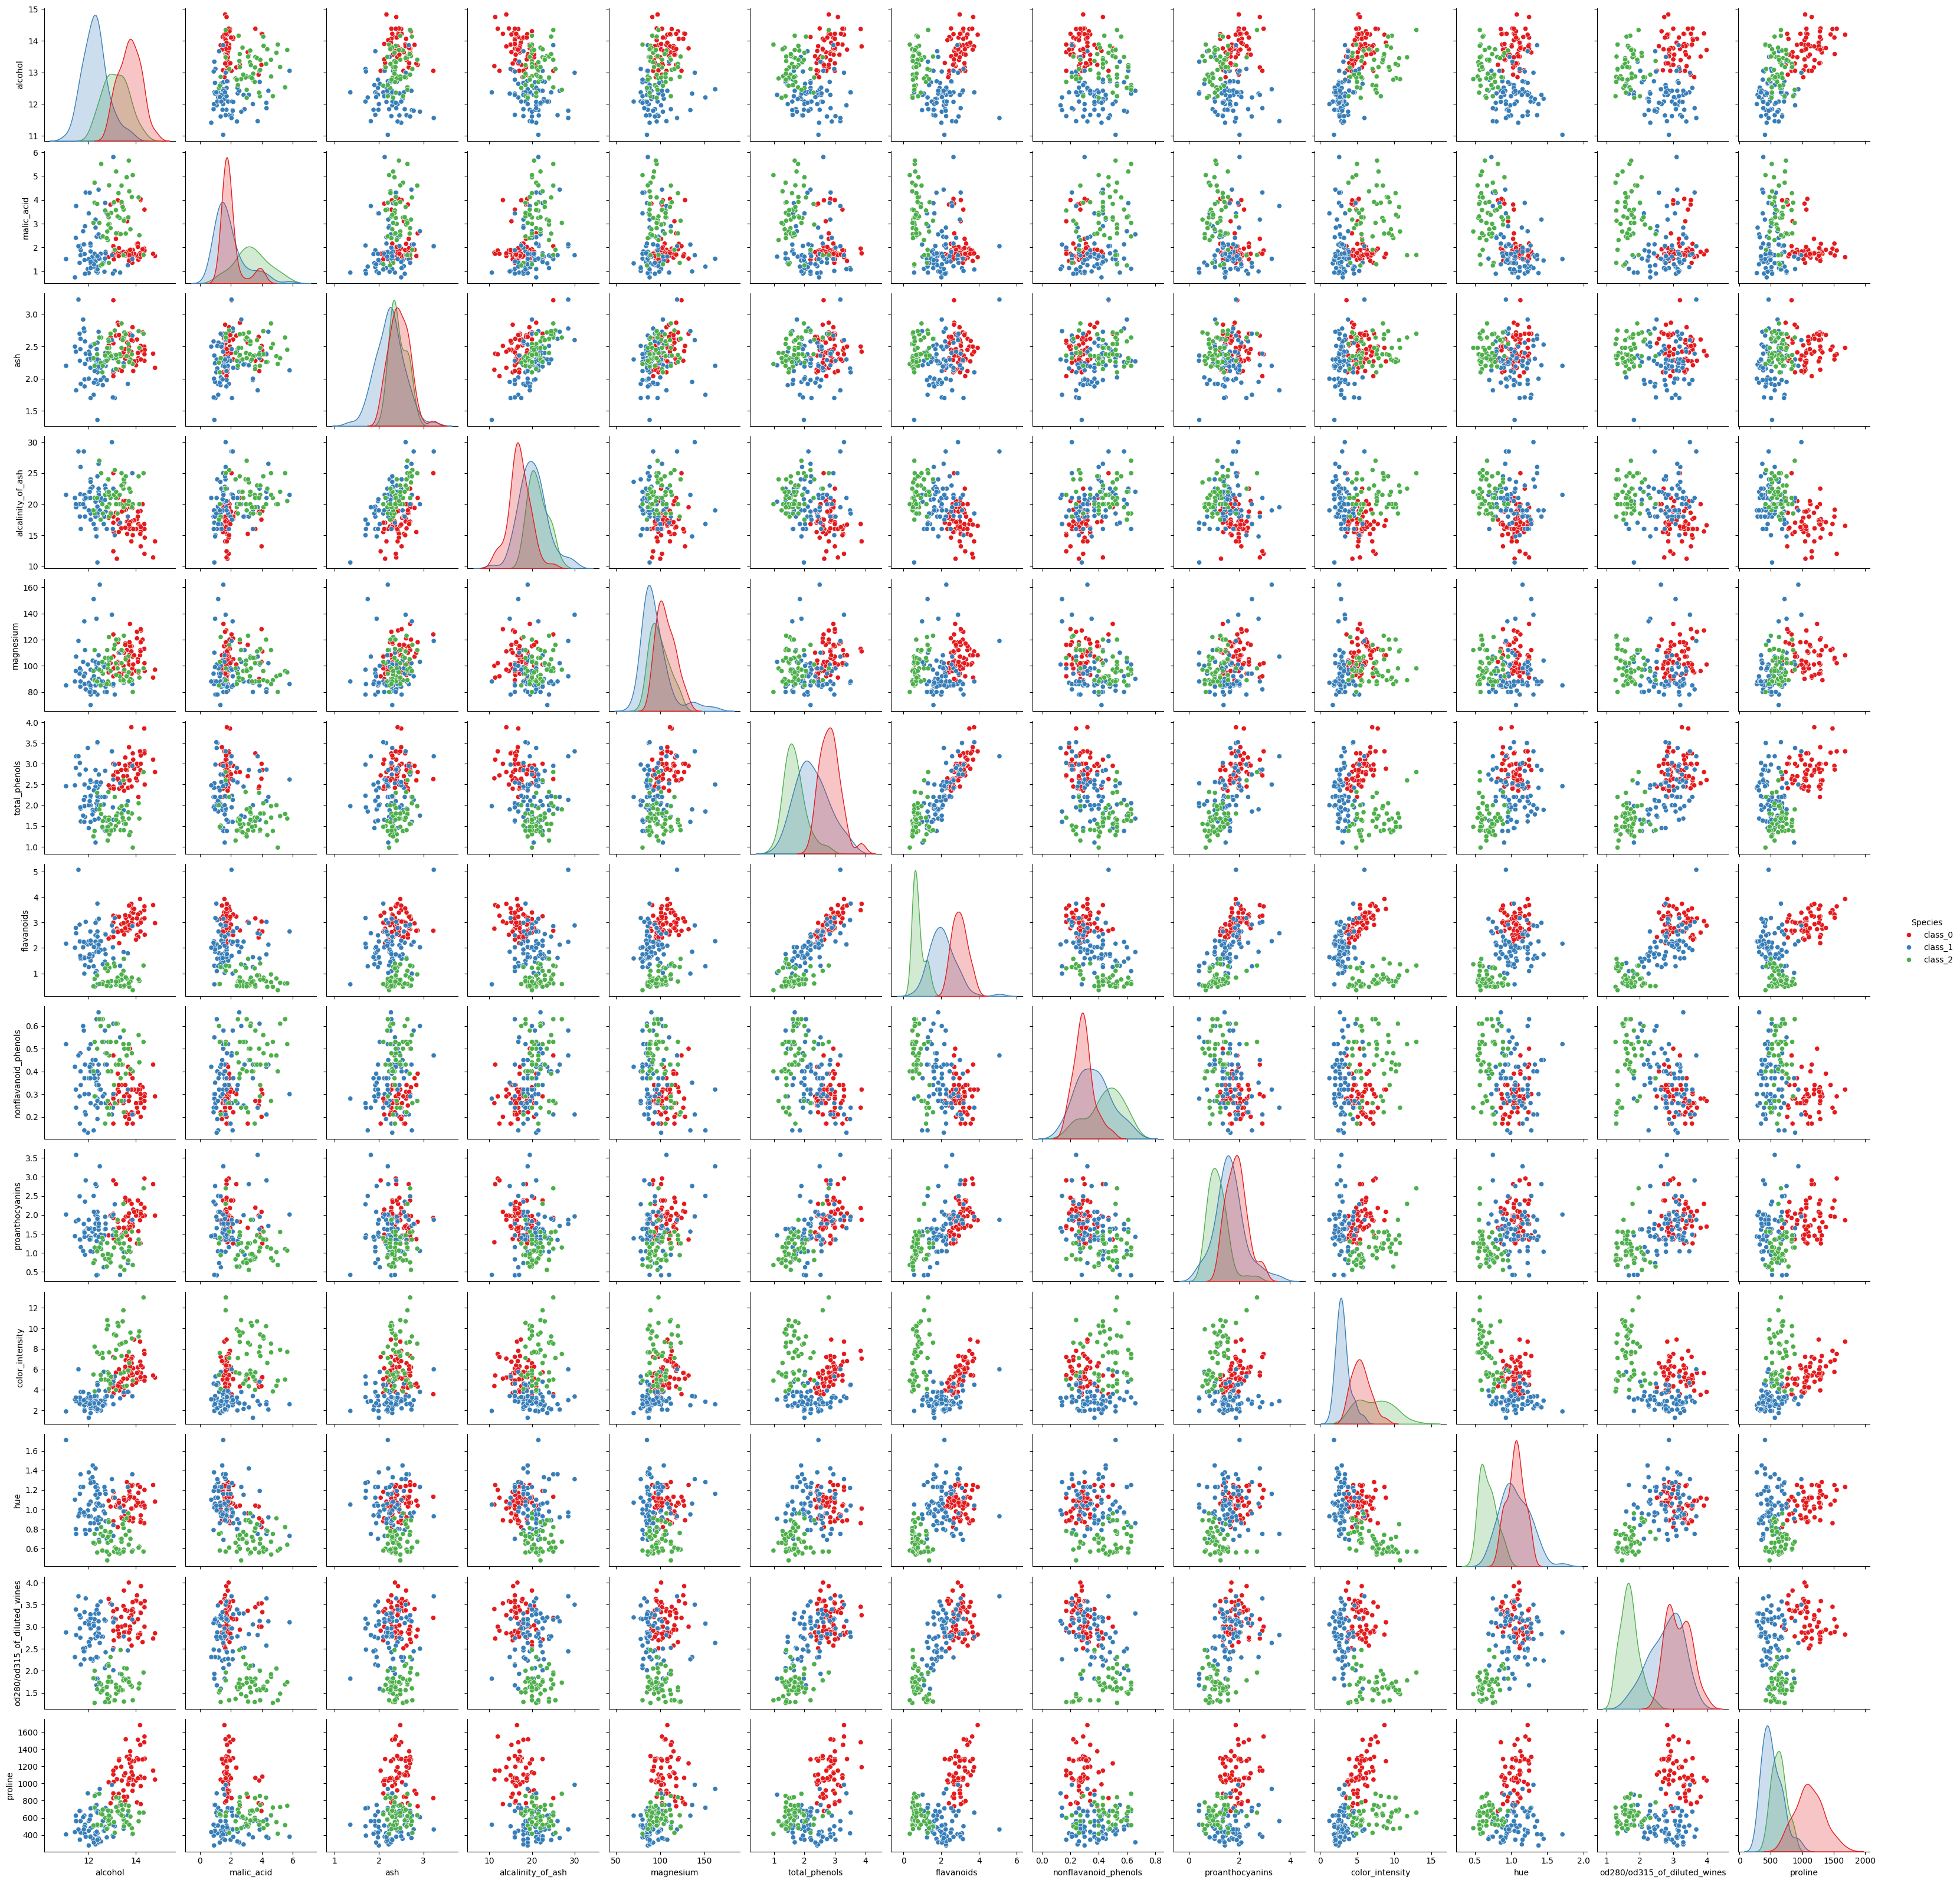

In [8]:
df = pd.DataFrame(X, columns=wine.feature_names)
df['Species'] = wine.target_names[y]
sns.pairplot(df, hue='Species', palette='Set1', diag_kind='kde')

In this section, I visualize the relationships between features in the Wine dataset using a pairplot, which provides insight into how features interact and how the classes are distributed.

pd.DataFrame(X, columns=wine.feature_names) – creates a DataFrame where each column corresponds to one of the 13 chemical attributes of wine.

df['Species'] = wine.target_names[y] – adds a categorical column representing the wine class name (e.g., class_0, class_1, class_2).

sns.pairplot() – from the Seaborn library, generates a grid of scatter plots showing the relationship between every pair of features.

*   hue='Species' – colors the points by class to visually distinguish categories.
*   palette='Set1' – sets a bright and clear color scheme for clarity.
*   diag_kind='kde' – displays Kernel Density Estimates on the diagonal instead of histograms, giving smoother visualizations of feature distributions.

This visualization helps reveal:

*   Which features provide good separation between wine classes.
*   Possible correlations between attributes.
*   The spread and overlap of data for each class.

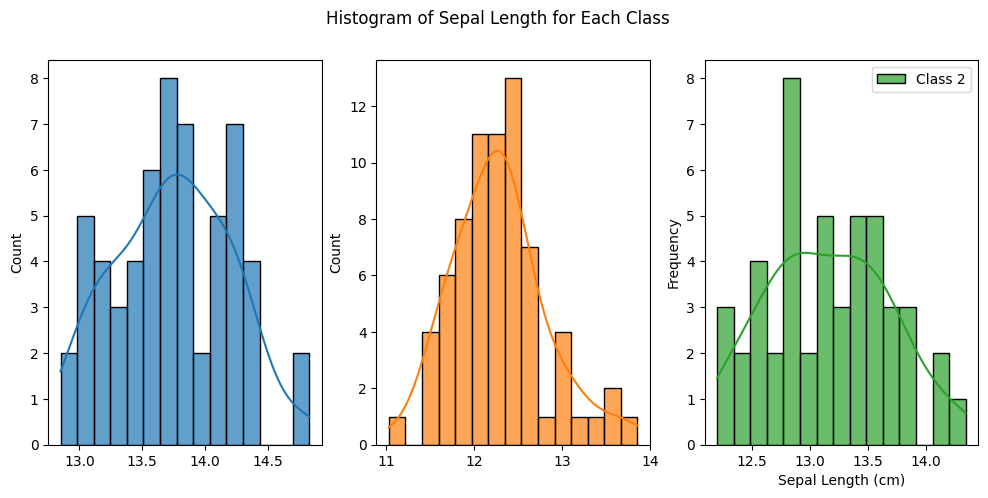

In [9]:
plt.figure(figsize=(12, 5))
for i in range(3):
  plt.subplot(1, 3, i + 1)
  sns.histplot(X[y == i][:, 0], bins=15, kde=True, label=class_names[i],
color=f'C{i}', alpha=0.7)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.legend()
plt.suptitle('Histogram of Sepal Length for Each Class');

This visualization shows how the first feature (e.g., “alcohol” in the Wine dataset) is distributed for each wine class.
By comparing histograms, we can observe how distinct or overlapping the feature values are among the classes.

plt.figure(figsize=(12, 5)) – creates a wide figure layout for displaying three subplots side by side.

The for loop – generates three histograms, one for each class (class_0, class_1, class_2).

sns.histplot() – plots a histogram with a smooth Kernel Density Estimate (KDE) curve:

*   X[y == i][:, 0] – selects the first feature for each class.
*   bins=15 – divides the data range into 15 intervals.
*   alpha=0.7 – sets transparency for better overlap visibility.
*   label=class_names[i] – assigns a label to each plot.

Axis labels and a title make the visualization clear and self-contained.

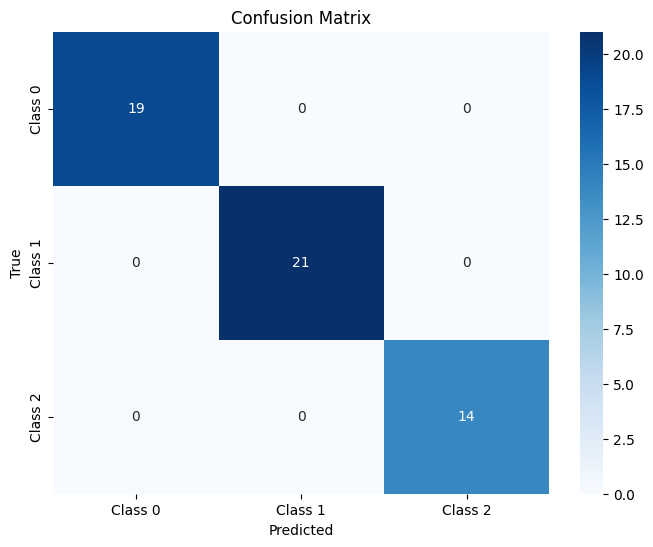

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues",
xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix");

This section visualizes the confusion matrix using a Seaborn heatmap to provide a clear, graphical summary of the model’s classification performance.

sns.heatmap() – displays the confusion matrix as a color-coded grid:

*   confusion – the matrix generated earlier comparing predicted vs actual labels.
*   annot=True – shows the actual numeric values in each cell.
*   fmt="d" – formats values as integers.
*   cmap="Blues" – applies a blue gradient color palette for better readability.
*   xticklabels / yticklabels – label the axes with class names.

plt.xlabel("Predicted") – marks the horizontal axis as Predicted Labels.

plt.ylabel("True") – marks the vertical axis as True Labels (actual classes).

The title “Confusion Matrix” summarizes what the plot represents.

In [11]:
url = "https://raw.githubusercontent.com/Abiliger/Intelligent-analysis-and-data-visualization/main/Healthcare-Diabetes.csv"
df_healthcare = pd.read_csv(url)
df_healthcare.head()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


In this step, I load a Healthcare Diabetes dataset directly from a public GitHub repository for further analysis and model testing.

*   url – contains the direct link to the raw CSV file hosted on GitHub.
*   pd.read_csv(url) – reads the dataset into a Pandas DataFrame named df_healthcare.
*   df_healthcare.head() – displays the first five rows of the dataset to confirm that the data was loaded correctly.

This dataset includes medical indicators such as:

Glucose level, Blood Pressure, BMI, Age, Pregnancies, and an Outcome variable (1 = Diabetic, 0 = Non-Diabetic).

It provides a practical example of applying machine learning algorithms like Naive Bayes or SVM in the healthcare domain to predict diabetes based on patient attributes.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)

In this step, I divide the Healthcare Diabetes dataset into separate subsets for training and testing the machine learning model.

train_test_split() – splits the dataset into random subsets for training and evaluation.

Parameters:

*   X, y – represent the feature matrix and the target variable (Outcome column, where 1 = diabetic and 0 = non-diabetic).
*   test_size=0.3 – assigns 30% of the data to the test set and 70% to the training set.
*   random_state=42 – ensures reproducibility by using a fixed random seed, so the same split occurs each time the code runs.

This approach allows the model to learn patterns from the training data and validate its performance on unseen test data — a crucial step for evaluating how well the model generalizes to new patients.

In [18]:
clf = GaussianNB()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In this section, I train the Gaussian Naive Bayes classifier on the Healthcare Diabetes dataset and use it to make predictions on the test data.

GaussianNB() – creates an instance of the Gaussian Naive Bayes model. This algorithm assumes that features are independent and follow a normal (Gaussian) distribution, making it simple yet effective for medical and classification tasks.

clf.fit(X_train, y_train) – trains (fits) the model on the training dataset, learning the probability distributions for each feature relative to the target outcome (Diabetic or Non-Diabetic).

clf.predict(X_test) – applies the trained model to the test dataset to generate predictions (y_pred), which represent the model’s classification for unseen patients.

This process enables the model to estimate the likelihood of a patient having diabetes based on their health indicators such as glucose, BMI, and age.

In [20]:
class_names = ['Non-Diabetic', 'Diabetic']
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
print(" The result report:\n", classification_report(y_test, y_pred, target_names=class_names))

 The result report:
               precision    recall  f1-score   support

Non-Diabetic       0.82      0.86      0.84       562
    Diabetic       0.67      0.60      0.64       269

    accuracy                           0.78       831
   macro avg       0.75      0.73      0.74       831
weighted avg       0.77      0.78      0.77       831



This section evaluates the Naive Bayes classifier on the Healthcare Diabetes dataset using two key tools: a confusion matrix and a classification report.

confusion_matrix(y_test, y_pred) – generates a 2×2 matrix comparing true labels (y_test) with predicted labels (y_pred).

*   Each cell shows how many samples were correctly classified or misclassified.
*   Diagonal cells represent correct predictions, while off-diagonal cells indicate errors.

classification_report() – provides a detailed performance summary for both classes:

*   Precision – how many of the model’s positive predictions were correct.
*   Recall (Sensitivity) – how many actual positive cases were identified.
*   F1-score – the harmonic mean of precision and recall, offering a balanced performance metric.
*   Support – the number of true samples in each class.

output_dict=True – stores the results in dictionary format for further analysis or visualization.

The print() statement displays the formatted text report directly in the notebook.

In [21]:
accuracy = accuracy_score(y_test, y_pred)
print("The accuracy is:", accuracy)

The accuracy is: 0.776173285198556


This step computes the overall accuracy of the Naive Bayes model on the Healthcare (Diabetes) test dataset.

accuracy_score(y_test, y_pred) – measures the proportion of correctly predicted labels among all test samples.

The result is stored in the variable accuracy and printed in a readable format.

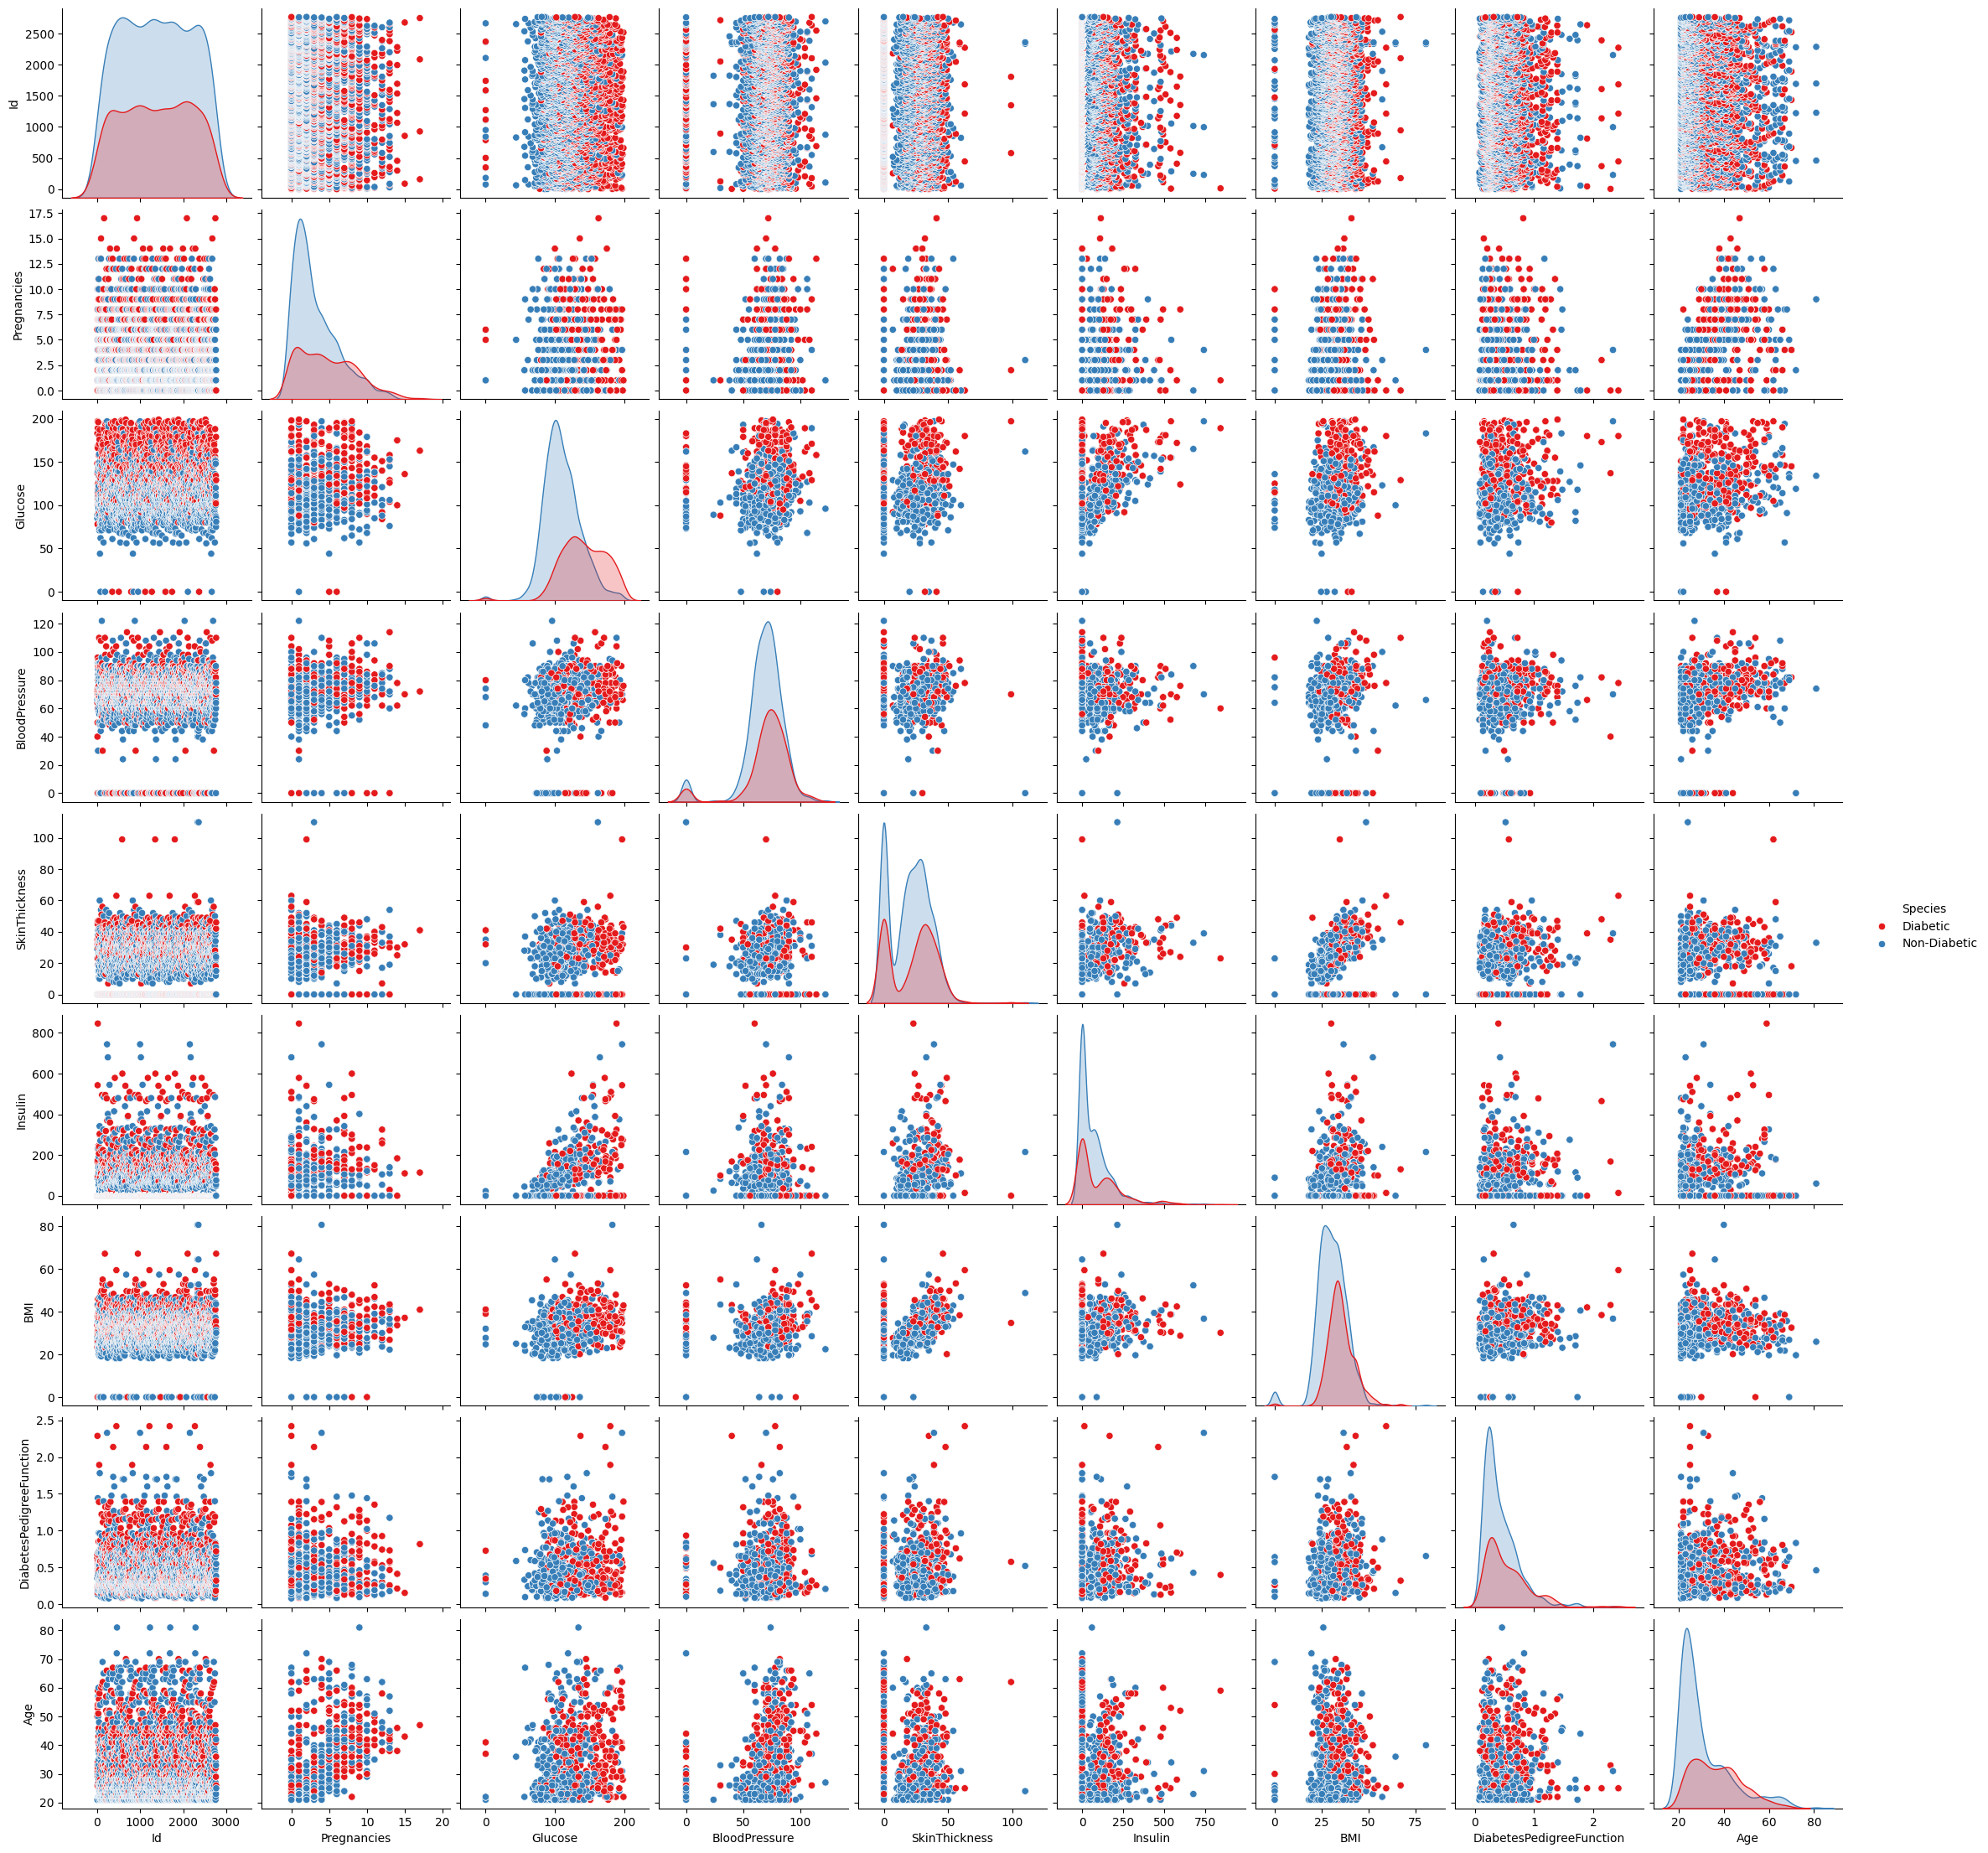

In [22]:
df = pd.DataFrame(X, columns=X.columns)
species = ['Non-Diabetic', 'Diabetic']
df['Species'] = [species[i] for i in y]
sns.pairplot(df, hue='Species', palette='Set1', diag_kind='kde')

This visualization helps explore the relationships between features and understand how they differ between diabetic and non-diabetic patients.

pd.DataFrame(X, columns=X.columns) – converts the feature matrix into a Pandas DataFrame, preserving column names for readability.

species = ['Non-Diabetic', 'Diabetic'] – defines class labels for clarity.

df['Species'] = [species[i] for i in y] – adds a new column to the DataFrame that maps each row to its respective class name.

sns.pairplot() – from Seaborn, creates a grid of scatter plots to show pairwise relationships between all numerical features.

hue='Species' – colors points according to class, allowing easy visual comparison.

palette='Set1' – uses bright, contrasting colors for distinction.

diag_kind='kde' – displays Kernel Density Estimate (KDE) curves along the diagonal to show feature distributions smoothly.

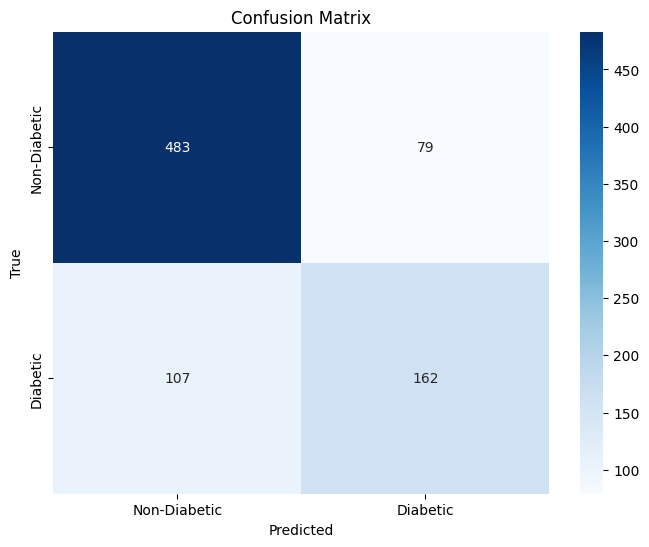

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues",
xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix");

This plot visualizes the confusion matrix for the Healthcare Diabetes dataset, allowing you to see where the Naive Bayes model performs well and where it makes classification errors.

sns.heatmap() – visualizes the confusion matrix as a color-coded grid.

*   annot=True – displays the actual numeric counts in each cell.
*   fmt="d" – formats the cell values as integers.
*   cmap="Blues" – applies a blue color scale to enhance readability.
*   xticklabels / yticklabels – label the axes with class names (“Non-Diabetic” and “Diabetic”).

plt.xlabel("Predicted") – shows predicted classes on the x-axis.

plt.ylabel("True") – shows actual (true) classes on the y-axis.

The title clearly identifies the visualization.